In [38]:
%store -r X_train
%store -r X_test
%store -r y_train
%store -r y_test
%store -r X_val
%store -r y_val

In [39]:
from tensorflow.keras.models import load_model
model = load_model("model_v2.h5")


In [40]:
import pickle

with open("history.pkl", "rb") as f:
    history_dict = pickle.load(f)

In [41]:
import numpy as np 
import pandas as pd 

In [42]:
loss, mae = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, MAE: {mae}, RMSE: {np.sqrt(loss)}, MAPE: {mae*100}, R2: {1 - loss}')

30/30 [==============================] - 0s 1ms/step - loss: 0.2584 - mae: 0.3262
Loss: 0.25835108757019043, MAE: 0.32620126008987427, RMSE: 0.5082824879633278, MAPE: 32.62012600898743, R2: 0.7416489124298096


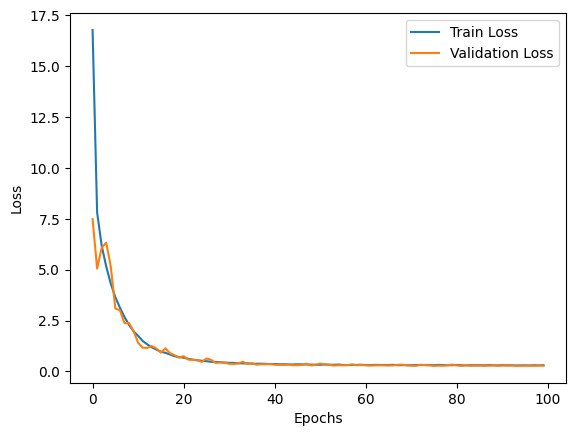

In [43]:
import matplotlib.pyplot as plt

plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predicciones

In [44]:
predictions = model.predict(X_test)
print(predictions[:10])

30/30 [==============================] - 0s 830us/step
[[ 9.47949 ]
 [ 9.619738]
 [10.076241]
 [ 9.876759]
 [10.938816]
 [ 9.936182]
 [10.896004]
 [ 9.480385]
 [11.881596]
 [ 9.430736]]


In [45]:
df_results = pd.DataFrame({'Real': y_test[:10].values, 'Predicción': predictions[:10].flatten()})
print(df_results)


        Real  Predicción
0   9.680406    9.479490
1   9.392745    9.619738
2  10.239996   10.076241
3   8.987322    9.876759
4  10.736418   10.938816
5   9.741027    9.936182
6  10.950824   10.896004
7   9.159152    9.480385
8  12.899222   11.881596
9   9.615872    9.430736


In [46]:
nueva_propiedad = np.array([[3, 1200, 5, 1, 3, 2, 53, 2, 2, 1]])  # Asegúrate de usar el mismo preprocesamiento que X_train
prediccion = model.predict(nueva_propiedad)

print(f"La renta estimada es: {prediccion[0][0]}")


1/1 [==============================] - 0s 40ms/step
La renta estimada es: 177.43531799316406
